In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load German Credit dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

col_names = [
    'status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings', 'employment', 'installment_rate', 'personal_status_sex',
    'other_debtors', 'residence', 'property', 'age', 'other_installments',
    'housing', 'existing_credits', 'job', 'dependents', 'telephone',
    'foreign_worker', 'target'
]

df_german = pd.read_csv(url, sep=' ', header=None, names=col_names)

print("Dataset loaded successfully")
print("Shape:", df_german.shape)
df_german.head()

Dataset loaded successfully
Shape: (1000, 21)


,status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
# ── CELL 2: Decode Gender and Target ──────────────
# personal_status_sex codes:
# A91 = male divorced, A92 = female, A93 = male single
# A94 = male married, A95 = female single
gender_map = {
    'A91': 'Male', 'A92': 'Female',
    'A93': 'Male', 'A94': 'Male', 'A95': 'Female'
}
df_german['gender'] = df_german['personal_status_sex'].map(gender_map)

# Target: 1 = Good credit, 2 = Bad credit
df_german['credit_risk'] = df_german['target'].map({1:'Good', 2:'Bad'})

print("=== GENDER DISTRIBUTION ===")
print(df_german['gender'].value_counts())

print("\n=== CREDIT RISK DISTRIBUTION ===")
print(df_german['credit_risk'].value_counts())

print("\n=== MISSING VALUES ===")
print(df_german.isnull().sum().sum(), "missing values total")

=== GENDER DISTRIBUTION ===
gender
Male      690
Female    310
Name: count, dtype: int64

=== CREDIT RISK DISTRIBUTION ===
credit_risk
Good    700
Bad     300
Name: count, dtype: int64

=== MISSING VALUES ===
0 missing values total


=== BAD CREDIT RATE BY GENDER (%) ===
gender
Female    35.16
Male      27.68
Name: target, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: '../results/german_bad_credit_by_gender.png'

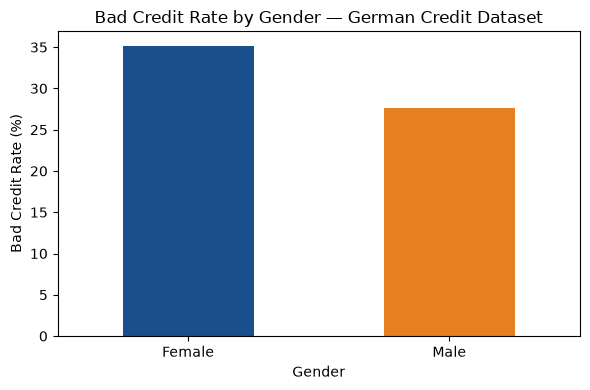

In [4]:
# ── CELL 3: Bias Signal — Credit Risk by Gender ───
bad_credit_by_gender = df_german.groupby('gender')['target'].apply(
    lambda x: (x==2).mean()*100).round(2)
print("=== BAD CREDIT RATE BY GENDER (%) ===")
print(bad_credit_by_gender)

plt.figure(figsize=(6,4))
bad_credit_by_gender.plot(kind='bar', color=['#1B4F8C','#E67E22'])
plt.title('Bad Credit Rate by Gender — German Credit Dataset')
plt.ylabel('Bad Credit Rate (%)')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/german_bad_credit_by_gender.png', dpi=150)
plt.show()

=== BAD CREDIT RATE BY AGE GROUP (%) ===
age_group
Young (<25)       42.11
Middle (25-45)    27.72
Older (>45)       25.27
Name: target, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: '../results/german_bad_credit_by_age.png'

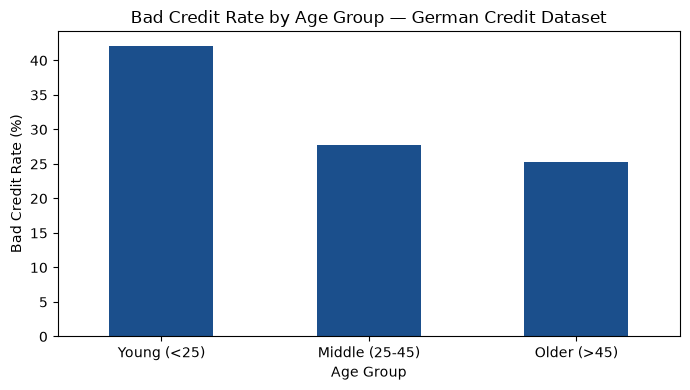

In [5]:
# ── CELL 4: Bias Signal — Credit Risk by Age ──────
# Define age groups: young (<25), middle (25-45), older (>45)
df_german['age_group'] = pd.cut(df_german['age'],
    bins=[0, 25, 45, 100],
    labels=['Young (<25)', 'Middle (25-45)', 'Older (>45)'])

bad_credit_by_age = df_german.groupby('age_group', observed=True)['target'].apply(
    lambda x: (x==2).mean()*100).round(2)

print("=== BAD CREDIT RATE BY AGE GROUP (%) ===")
print(bad_credit_by_age)

plt.figure(figsize=(7,4))
bad_credit_by_age.plot(kind='bar', color='#1B4F8C')
plt.title('Bad Credit Rate by Age Group — German Credit Dataset')
plt.ylabel('Bad Credit Rate (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/german_bad_credit_by_age.png', dpi=150)
plt.show()

# EDA Summary
print("\n=== EDA SUMMARY — GERMAN CREDIT DATASET ===")
print(f"Total records:          {len(df_german):,}")
print(f"Missing values:         0")
print(f"Good credit rate:       {(df_german['target']==1).mean()*100:.1f}%")
print(f"Bad credit rate:        {(df_german['target']==2).mean()*100:.1f}%")
print(f"Male bad credit rate:   {bad_credit_by_gender.get('Male',0):.1f}%")
print(f"Female bad credit rate: {bad_credit_by_gender.get('Female',0):.1f}%")
print("\nEDA COMPLETE — German Credit dataset ready for preprocessing")

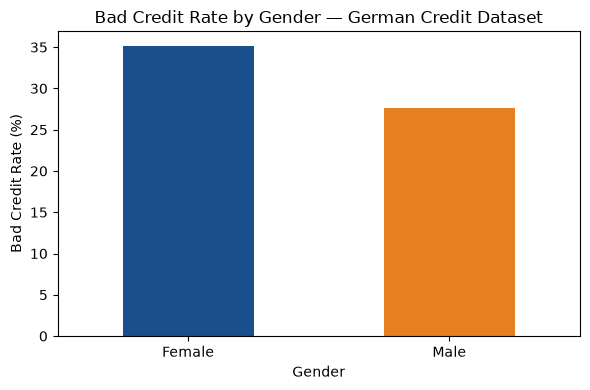

Gender chart saved successfully


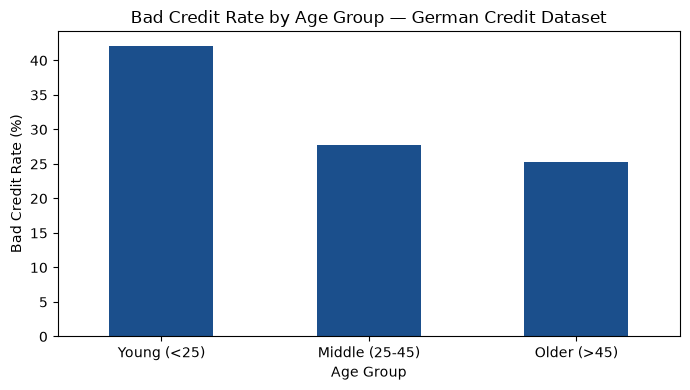

Age chart saved successfully

=== EDA SUMMARY — GERMAN CREDIT DATASET ===
Total records:          1,000
Good credit rate:       70.0%
Bad credit rate:        30.0%
Male bad credit rate:   27.7%
Female bad credit rate: 35.2%

EDA COMPLETE — German Credit dataset ready for preprocessing


In [6]:
# Fix saving path for Windows
import os

# Create results folder directly using full path
results_path = r'C:\Users\niyat\Desktop\pr\ML-Bias-Fairness\results'
os.makedirs(results_path, exist_ok=True)

# Recreate and save gender chart
bad_credit_by_gender = df_german.groupby('gender')['target'].apply(
    lambda x: (x==2).mean()*100).round(2)

plt.figure(figsize=(6,4))
bad_credit_by_gender.plot(kind='bar', color=['#1B4F8C','#E67E22'])
plt.title('Bad Credit Rate by Gender — German Credit Dataset')
plt.ylabel('Bad Credit Rate (%)')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(results_path, 'german_bad_credit_by_gender.png'), dpi=150)
plt.show()
print("Gender chart saved successfully")

# Recreate and save age chart
df_german['age_group'] = pd.cut(df_german['age'],
    bins=[0, 25, 45, 100],
    labels=['Young (<25)', 'Middle (25-45)', 'Older (>45)'])

bad_credit_by_age = df_german.groupby('age_group', observed=True)['target'].apply(
    lambda x: (x==2).mean()*100).round(2)

plt.figure(figsize=(7,4))
bad_credit_by_age.plot(kind='bar', color='#1B4F8C')
plt.title('Bad Credit Rate by Age Group — German Credit Dataset')
plt.ylabel('Bad Credit Rate (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(results_path, 'german_bad_credit_by_age.png'), dpi=150)
plt.show()
print("Age chart saved successfully")

# Final summary
print("\n=== EDA SUMMARY — GERMAN CREDIT DATASET ===")
print(f"Total records:          {len(df_german):,}")
print(f"Good credit rate:       {(df_german['target']==1).mean()*100:.1f}%")
print(f"Bad credit rate:        {(df_german['target']==2).mean()*100:.1f}%")
print(f"Male bad credit rate:   {bad_credit_by_gender.get('Male',0):.1f}%")
print(f"Female bad credit rate: {bad_credit_by_gender.get('Female',0):.1f}%")
print("\nEDA COMPLETE — German Credit dataset ready for preprocessing")